In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
!pip install kagglehub[pandas-datasets]
import kagglehub
import os
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

Path to competition files: C:\Users\LENOVO\.cache\kagglehub\competitions\playground-series-s6e6


In [24]:
print(os.listdir(path))

['sample_submission.csv', 'test.csv', 'train.csv']


In [25]:
train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(train_df.shape)
print(test_df.shape)

train_df.head()

(577347, 12)
(247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [26]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())
test_df.head()

0
0


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [27]:
target_col = [col for col in train_df.columns if col not in test_df.columns and col != 'id'][0]
print(f"Target Column Identified: '{target_col}'")
print("\nTarget Class Distribution:")
print(train_df[target_col].value_counts(normalize=True) * 100)

Target Column Identified: 'class'

Target Class Distribution:
class
GALAXY    65.381824
QSO       20.289878
STAR      14.328298
Name: proportion, dtype: float64


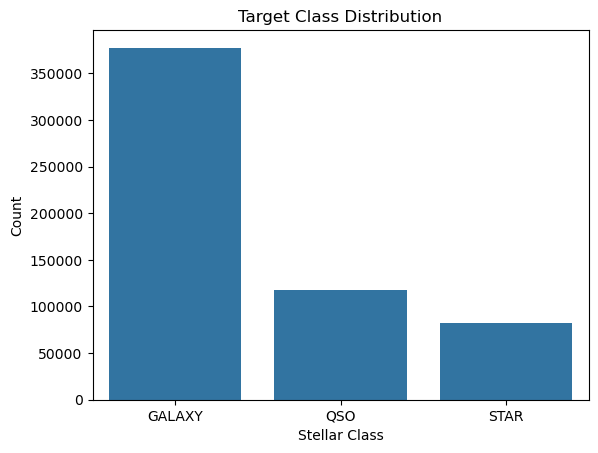

In [28]:
sns.countplot(data=train_df, x=target_col)
plt.title('Target Class Distribution')
plt.xlabel('Stellar Class')
plt.ylabel('Count')
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

def create_astronomical_features(df):
    df_feat = df.copy()
    
    df_feat['u_g'] = df_feat['u'] - df_feat['g']
    df_feat['g_r'] = df_feat['g'] - df_feat['r']
    df_feat['r_i'] = df_feat['r'] - df_feat['i']
    df_feat['i_z'] = df_feat['i'] - df_feat['z']
    df_feat['u_r'] = df_feat['u'] - df_feat['r']
    
    df_feat['ug_ratio'] = df_feat['u'] / (df_feat['g'] + 1e-6)
    df_feat['gr_ratio'] = df_feat['g'] / (df_feat['r'] + 1e-6)
    
    return df_feat

train_fe = create_astronomical_features(train_df)
test_fe = create_astronomical_features(test_df)

X = train_fe.drop(columns=['id', 'class'])
y_raw = train_fe['class']
X_test_final = test_fe.drop(columns=['id'])
X = pd.get_dummies(X, columns=['spectral_type', 'galaxy_population'], drop_first=True)
X_test_final = pd.get_dummies(X_test_final, columns=['spectral_type', 'galaxy_population'], drop_first=True)
X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

In [30]:
print(f"Processed Train Shape: {X.shape} | Processed Test Shape: {X_test_final.shape}")

Processed Train Shape: (577347, 19) | Processed Test Shape: (247435, 19)


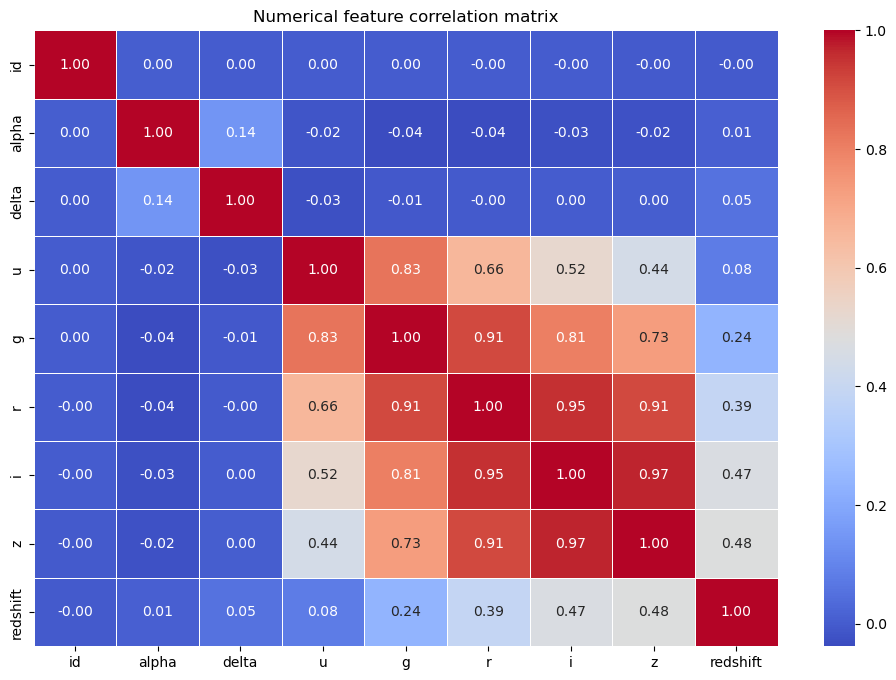

In [31]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Numerical feature correlation matrix")
plt.show()

In [32]:
upper_tri = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print("Potentially Redundant Features (Correlation > 0.95):", redundant_cols)

Potentially Redundant Features (Correlation > 0.95): ['i', 'z']


In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
dt_model = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]
    
    dt_model.fit(X_tr, y_tr)
    preds = dt_model.predict(X_va)
    dt_scores.append(balanced_accuracy_score(y_va, preds))
    
print(f"Decision Tree Mean Balanced Accuracy: {np.mean(dt_scores):.4f}")

Decision Tree Mean Balanced Accuracy: 0.8908


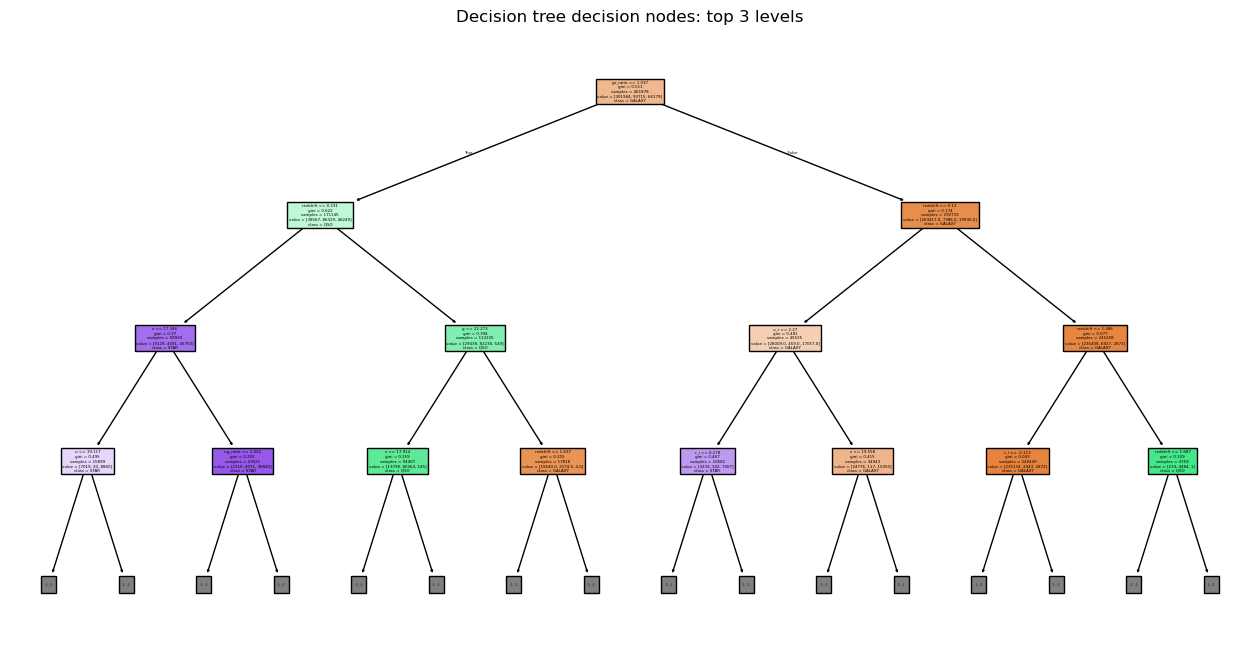

In [36]:
plt.figure(figsize=(16, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=label_enc.classes_, filled=True, max_depth=3)
plt.title("Decision tree decision nodes: top 3 levels")
plt.show()

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]
    
    rf_model.fit(X_tr, y_tr)
    preds = rf_model.predict(X_va)
    rf_scores.append(balanced_accuracy_score(y_va, preds))

print(f"Random Forest Mean Balanced Accuracy: {np.mean(rf_scores):.4f}")

Random Forest Mean Balanced Accuracy: 0.9310


In [39]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

oof_preds_xgb = np.zeros((len(X), 3))
oof_preds_rf = np.zeros((len(X), 3))
test_preds_xgb = np.zeros((len(X_test_final), 3))
test_preds_rf = np.zeros((len(X_test_final), 3))

In [40]:
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]
    
    # Fit XGBoost
    xgb_model.fit(X_tr, y_tr)
    oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_va)
    test_preds_xgb += xgb_model.predict_proba(X_test_final) / 5.0
    
    # Fit RF
    rf_model.fit(X_tr, y_tr)
    oof_preds_rf[val_idx] = rf_model.predict_proba(X_va)
    test_preds_rf += rf_model.predict_proba(X_test_final) / 5.0
    
    fold_acc = balanced_accuracy_score(y_va, np.argmax(oof_preds_xgb[val_idx], axis=1))
    xgb_scores.append(fold_acc)

print(f"XGBoost mean balanced accuracy: {np.mean(xgb_scores):.4f}")

XGBoost mean balanced accuracy: 0.9487


In [41]:
blend_oof = (0.7 * oof_preds_xgb) + (0.3 * oof_preds_rf)
blend_preds_class = np.argmax(blend_oof, axis=1)

print(f"Blended Ensemble Balanced Accuracy: {balanced_accuracy_score(y, blend_preds_class):.4f}")

Blended Ensemble Balanced Accuracy: 0.9467


In [42]:
!pip install shap
import shap

explainer = shap.TreeExplainer(xgb_model)
sample_X = X.sample(1000, random_state=42)
shap_values = explainer(sample_X)

Actual Target Label for Sample 1: GALAXY


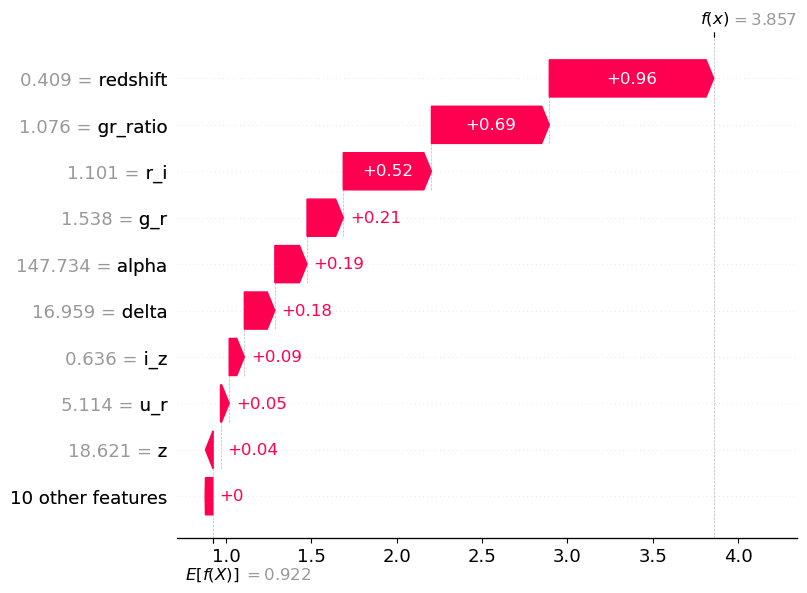

Actual Target Label for Sample 2: GALAXY


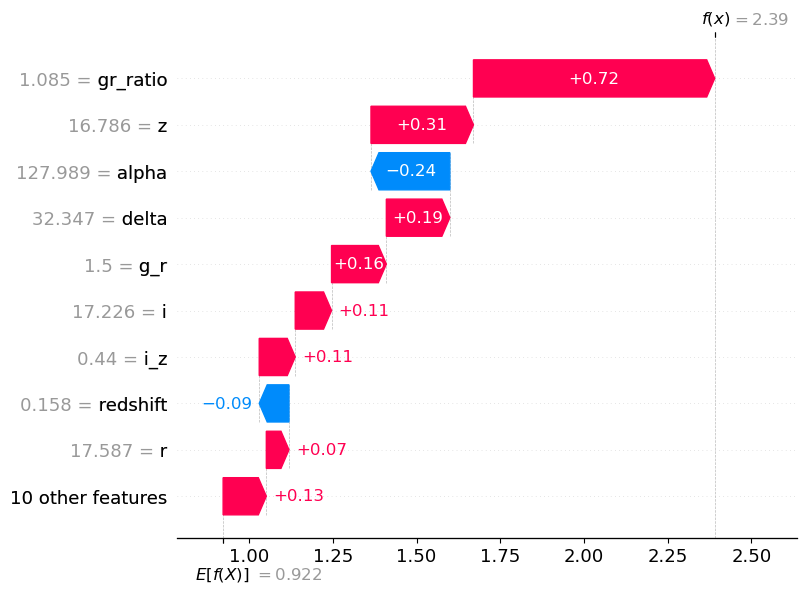

In [43]:
sample_1 = X.iloc[[0]]
sample_2 = X.iloc[[1]]

shap_values_sample1 = explainer(sample_1)
print(f"Actual Target Label for Sample 1: {label_enc.inverse_transform([y[0]])[0]}")
shap.plots.waterfall(shap_values_sample1[0, :, 0]) # Explanation for Class 0

shap_values_sample2 = explainer(sample_2)
print(f"Actual Target Label for Sample 2: {label_enc.inverse_transform([y[1]])[0]}")
shap.plots.waterfall(shap_values_sample2[0, :, 0])

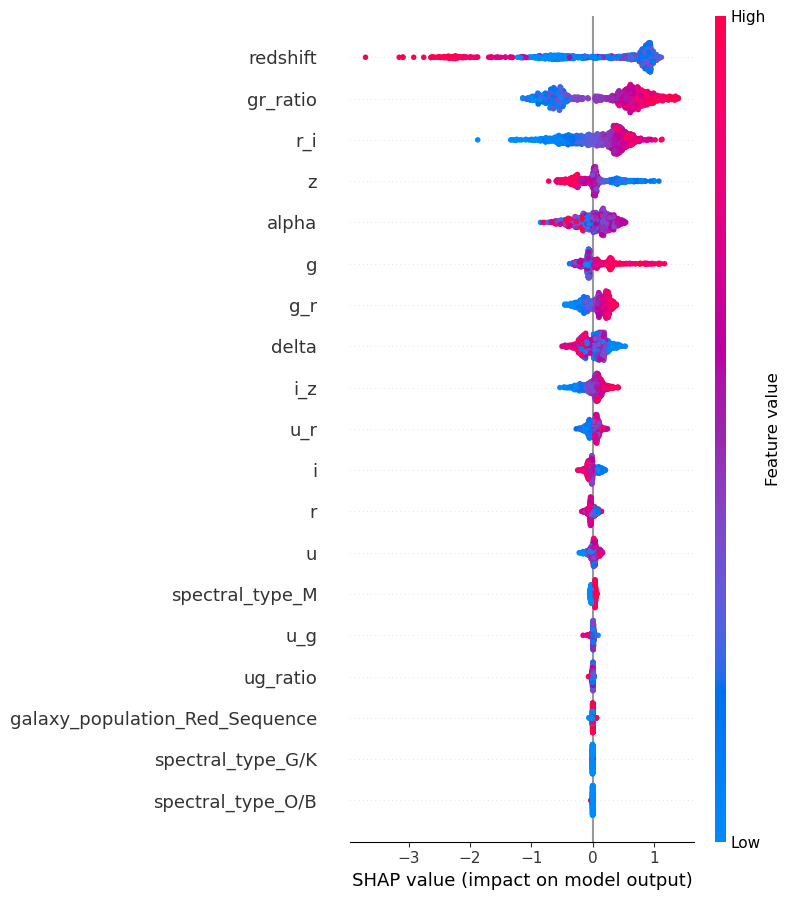

In [44]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 0], sample_X)

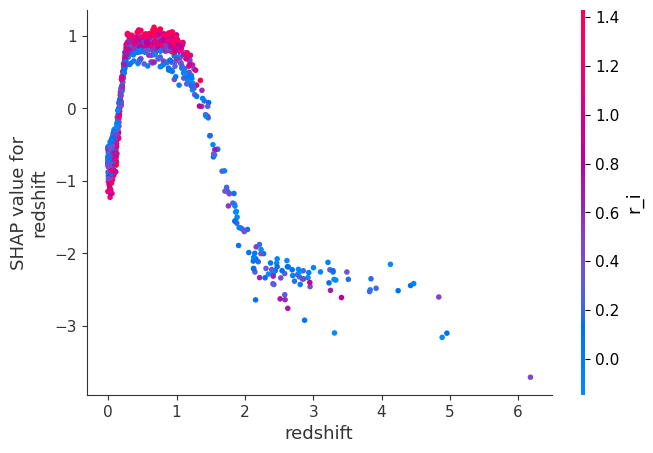

In [45]:
shap.dependence_plot("redshift", shap_values[:, :, 0].values, sample_X)

In [46]:
final_blend_test = (0.7 * test_preds_xgb) + (0.3 * test_preds_rf)
final_test_labels = label_enc.inverse_transform(np.argmax(final_blend_test, axis=1))

submission = pd.DataFrame({
    'id': test_df['id'],
    'class': final_test_labels
})

submission.to_csv("submission.csv", index=False)
print("Submission saved successfully!")
print(submission.head())

Submission saved successfully!
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY


In [ ]:

# from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier, RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_score, recall_score, f1_score
# from xgboost import XGBClassifier

# rf_base = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
# xgb_base = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
# gbc_base = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# estimators = [
#     ('rf', rf_base),
#     ('xgb', xgb_base),
#     ('gbc', gbc_base)
# ]


from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

models = {
    'AdaBoost': ada,
    'GradientBoosting': gbc,
    'XGBoost': xgb_model,
    'RandomForest': rf_model
}

for name, model in models.items():
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        scores.append(balanced_accuracy_score(y_va, preds))
    print(f"Model: {name:18s} | Mean Balanced Accuracy: {np.mean(scores):.4f}")

estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('gbc', gbc)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=200),
    cv=3, # Reduced folds from 5 to 3
    n_jobs=-1
)

print("Training Optimized Stacking Classifier...")
stacking_clf.fit(X, y)
print("Training Complete!")

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

ada_fast = AdaBoostClassifier(n_estimators=30, learning_rate=0.1, random_state=42)
gbc_fast = GradientBoostingClassifier(n_estimators=30, learning_rate=0.1, max_depth=3, random_state=42)


models = {
    'AdaBoost': ada_fast,
    'GradientBoosting': gbc_fast,
    'XGBoost': xgb_model,
    'RandomForest': rf_model
}


skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    scores = []
    for train_idx, val_idx in skf_fast.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        scores.append(balanced_accuracy_score(y_va, preds))
    print(f"Model: {name:18s} | Mean Balanced Accuracy: {np.mean(scores):.4f}")

estimators_fast = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('gbc', gbc_fast)
]

stacking_clf = StackingClassifier(
    estimators=estimators_fast,
    final_estimator=LogisticRegression(max_iter=100),
    cv=2,        
    n_jobs=-1    
)

print("\nTraining Lightweight Stacking Classifier...")
stacking_clf.fit(X, y)
print("Training Complete!")

In [ ]:
def print_full_metrics(y_true, y_pred, model_name):
    print(f"=== {model_name} Metrics ===")
    print(f"Balanced Accuracy : {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score ': {f1_score(y_true, y_pred, average='macro'):.4f}\n")

In [ ]:
import joblib
joblib.dump(xgb_model, 'xgb_stellar_model.pkl')
joblib.dump(label_enc, 'label_encoder.pkl')

['label_encoder.pkl']